In [9]:
# Viewing and understanding the data before cleansing

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [11]:
path = "building-dataset.csv" 

df = pd.read_csv(path)

In [12]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     43848 non-null  object 
 1   ENERGY   43746 non-null  float64
 2   HDD18_3  43848 non-null  float64
 3   CDD0     43848 non-null  float64
 4   CDD10    43848 non-null  float64
 5   PRECTOT  43848 non-null  float64
 6   RH2M     43848 non-null  float64
 7   T2M      43848 non-null  float64
 8   T2M_MIN  43848 non-null  float64
 9   T2M_MAX  43848 non-null  float64
 10  ALLSKY   43704 non-null  float64
 11  HOLIDAY  43848 non-null  int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 4.0+ MB


,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY
count,43746.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43704.000000,43848.000000
mean,165.581130,6.365280,13.011190,4.604367,1.367048,65.738777,12.510323,6.861189,19.157196,4.558859,0.402299
std,72.326392,5.536065,6.996848,5.303725,3.065327,17.283870,7.263277,5.878058,8.466543,2.353967,0.490367
min,47.933000,0.000000,0.000000,0.000000,0.000000,24.090000,-2.620000,-5.860000,2.760000,0.270000,0.000000
25%,117.624250,0.000000,7.040000,0.000000,0.000000,51.650000,6.390000,2.200000,12.030000,2.370000,0.000000
50%,131.877500,6.190000,12.110000,2.110000,0.080000,65.890000,11.710000,6.430000,18.170000,4.450000,0.000000
75%,202.501750,11.260000,19.040000,9.040000,1.280000,80.890000,18.670000,11.680000,26.270000,6.730000,1.000000
max,469.756000,19.690000,29.010000,19.010000,46.170000,100.000000,28.630000,20.960000,38.660000,8.670000,1.000000


In [13]:
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE")
df = df.set_index("DATE")

In [14]:
target_col = "ENERGY"

In [15]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

df["month"] = df.index.month

# Determining if day of week makes a difference in energy usage
df["is_weekend"] = np.where(df["dayofweek"] >= 5, 1, 0)

target = "ENERGY"

weather_features = [
    "HDD18_3",
    "CDD0",
    "CDD10",
    "T2M",
    "T2M_MIN",
    "T2M_MAX",
    "RH2M",
    "PRECTOT",
    "ALLSKY"
]

In [16]:
model_features = weather_features + [
    "HOLIDAY",
    "hour",
    "dayofweek",
    "month",
    "is_weekend"
]

In [17]:
df[feature_cols + [target_col]].dtypes

HDD18_3    float64
CDD0       float64
CDD10      float64
T2M        float64
T2M_MIN    float64
T2M_MAX    float64
RH2M       float64
PRECTOT    float64
ALLSKY     float64
ENERGY     float64
dtype: object

In [18]:
time_deltas = df.index.to_series().diff().dropna()

time_deltas.value_counts().head()

DATE
0 days 01:00:00    43839
0 days 02:00:00        4
0 days 00:00:00        4
Name: count, dtype: int64

In [19]:
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")

missing_times = full_index.difference(df.index)

len(missing_times), missing_times[:10]

(4,
 DatetimeIndex(['2016-03-27 03:00:00', '2018-03-25 03:00:00',
                '2019-03-31 03:00:00', '2020-03-29 03:00:00'],
               dtype='datetime64[ns]', freq=None))

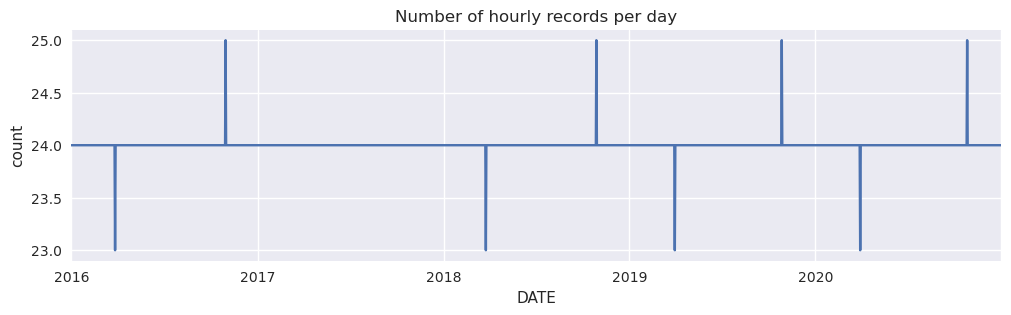

In [20]:
# Looking for days with missing hourly records. It appears there are none. 

df["present"] = 1
daily_counts = df["present"].resample("D").sum()

daily_counts.plot(figsize=(12, 3))
plt.title("Number of hourly records per day")
plt.ylabel("count")
plt.show()

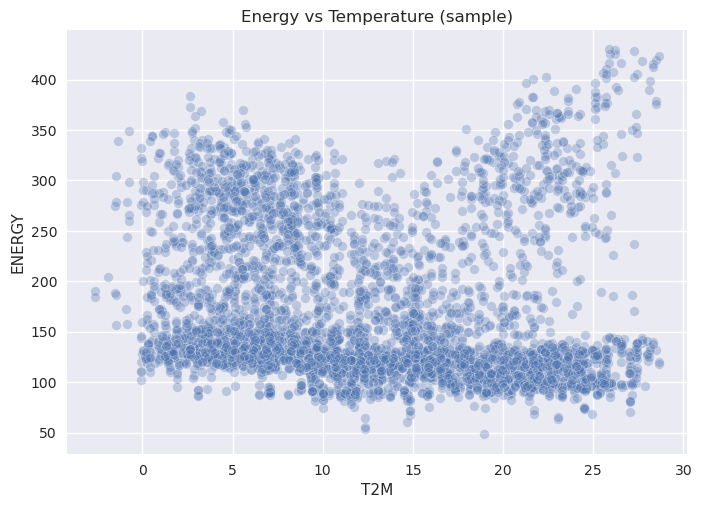

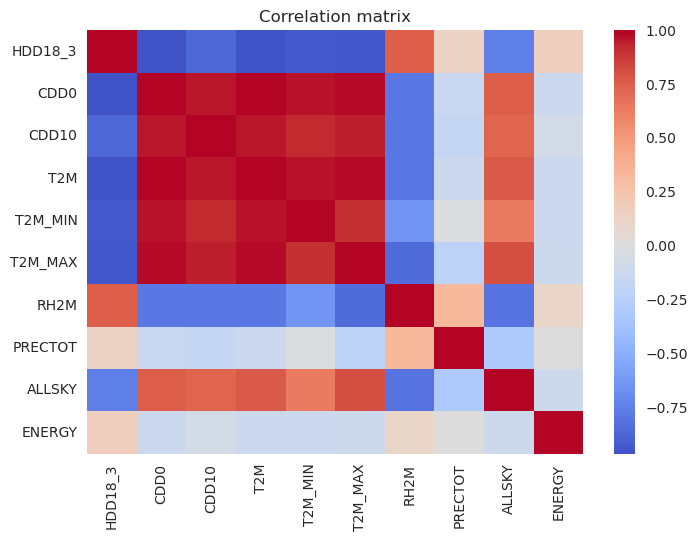

In [21]:
sns.scatterplot(data=df.sample(5000, random_state=0), x="T2M", y="ENERGY", alpha=0.3)
plt.title("Energy vs Temperature (sample)")
plt.show()

sns.heatmap(df[feature_cols + [target_col]].corr(), cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

In [22]:
# Scatter plot (graph 1): Shows the relationship between outdoor temperature and hourly building energy consumption, revealing whether energy demand changes in a simple linear way or shows a more complex pattern.
# Correlation matrix (graph 2): Shows how strongly each pair of variables moves together, highlighting which weather and calendar features are most closely related to both each other and to hourly building energy consumption.